# EDA

In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
path_to_dataset = "../data/raw/FraudDetection.csv"

if not os.path.isfile(path_to_dataset):
    print("not good")

In [3]:
df = pd.read_csv(path_to_dataset)

df.shape

(50000, 21)

### Info Dimensiune

-   50 de mii de observatii

-   21 de feature uri

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

In [6]:
df.describe()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.05020,0.098400,7.485240,255.271924,2.003540,119.999940,2499.164155,0.501556,0.299640,0.321340
std,98.687292,28760.458557,0.21836,0.297858,4.039637,141.382279,1.414273,68.985817,1442.013834,0.287774,0.458105,0.466996
min,0.000000,500.480000,0.00000,0.000000,1.000000,10.000000,0.000000,1.000000,0.250000,0.000100,0.000000,0.000000
25%,28.677500,25355.995000,0.00000,0.000000,4.000000,132.087500,1.000000,60.000000,1256.497500,0.254000,0.000000,0.000000
50%,69.660000,50384.430000,0.00000,0.000000,7.000000,256.085000,2.000000,120.000000,2490.785000,0.502250,0.000000,0.000000
75%,138.852500,75115.135000,0.00000,0.000000,11.000000,378.032500,3.000000,180.000000,3746.395000,0.749525,1.000000,1.000000
max,1174.140000,99998.310000,1.00000,1.000000,14.000000,500.000000,4.000000,239.000000,4999.930000,1.000000,1.000000,1.000000


### OBS:

Putem vedea posibili outlieri, de exemplu la variabila Transaction_Amount:

-   La pragul de 75%, valoarea este de 138.85. Ca valoare maxima avem 1174.14 care este de aproximativ 8 ori mai mare (discrepanta uriasa)

In [ ]:
df.isna().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### OBS:

-   Nu avem NA uri si valori duplicate

In [9]:
df.dtypes

Transaction_ID                      str
User_ID                             str
Transaction_Amount              float64
Transaction_Type                    str
Timestamp                           str
Account_Balance                 float64
Device_Type                         str
Location                            str
Merchant_Category                   str
IP_Address_Flag                   int64
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count           int64
Avg_Transaction_Amount_7d       float64
Failed_Transaction_Count_7d       int64
Card_Type                           str
Card_Age                          int64
Transaction_Distance            float64
Authentication_Method               str
Risk_Score                      float64
Is_Weekend                        int64
Fraud_Label                       int64
dtype: object

In [10]:
df.select_dtypes(include=['str'])

,Transaction_ID,User_ID,Transaction_Type,Timestamp,Device_Type,Location,Merchant_Category,Card_Type,Authentication_Method
0,TXN_33553,USER_1834,POS,2023-08-14 19:30:00,Laptop,Sydney,Travel,Amex,Biometric
1,TXN_9427,USER_7875,Bank Transfer,2023-06-07 04:01:00,Mobile,New York,Clothing,Mastercard,Password
2,TXN_199,USER_2734,Online,2023-06-20 15:25:00,Tablet,Mumbai,Restaurants,Visa,Biometric
3,TXN_12447,USER_2617,ATM Withdrawal,2023-12-07 00:31:00,Tablet,New York,Clothing,Visa,OTP
4,TXN_39489,USER_2014,POS,2023-11-11 23:44:00,Mobile,Mumbai,Electronics,Mastercard,Password
...,...,...,...,...,...,...,...,...,...
49995,TXN_11284,USER_4796,Online,2023-01-29 18:38:00,Mobile,Tokyo,Clothing,Amex,PIN
49996,TXN_44732,USER_1171,POS,2023-05-09 08:55:00,Mobile,Tokyo,Clothing,Visa,Biometric
49997,TXN_38158,USER_2510,Online,2023-01-30 19:32:00,Laptop,Mumbai,Clothing,Visa,Biometric
49998,TXN_860,USER_2248,Bank Transfer,2023-03-09 19:47:00,Mobile,Tokyo,Electronics,Discover,Biometric


In [11]:
df_text = df.select_dtypes(include=['str'])

In [13]:
(df_text == "").sum()

Transaction_ID           0
User_ID                  0
Transaction_Type         0
Timestamp                0
Device_Type              0
Location                 0
Merchant_Category        0
Card_Type                0
Authentication_Method    0
dtype: int64

### OBS

-   Nu avem nici empty strings

### Sa investigam Risk_Score

-   Stim deja ca valorile variabilei sunt rezultatele unei functii de activare sigmoid specifice regresiei logistice

In [14]:
# 1. Comparam mediile

df.groupby('Fraud_Label')['Risk_Score'].mean()

Fraud_Label
0    0.425158
1    0.662904
Name: Risk_Score, dtype: float64

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_74386/1270459240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Fraud_Label', y='Risk_Score', data=df, inner="quartile", palette="muted")


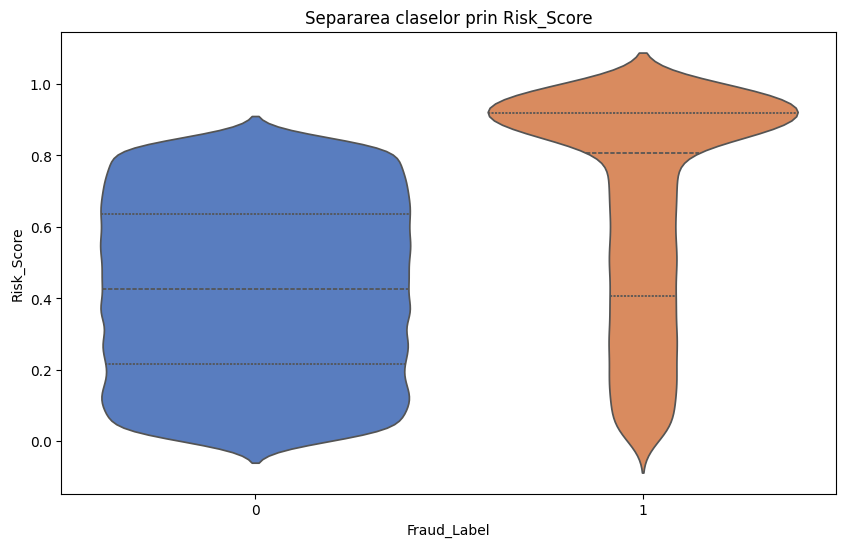

In [ ]:
# 2. Violin plot

plt.figure(figsize=(10, 6))
sns.violinplot(x='Fraud_Label', y='Risk_Score', data=df, inner="quartile", palette="muted")
plt.title('Separarea claselor prin Risk_Score')
plt.show()

### OBS

Din analiza mediilor:

-   Exista o diferenta de aprox 0.24 intre mediile celor doua clase. Asta inseamna ca Risk_Score are putere de discriminare (variabila ar putea fi utila in procesul de decizie)

Din Violin Plot:

-   Portocaliu = Frauda: Multe valori sus (0.8 - 1.0) -> Asta inseamna ca sistemul este foarte bun la a identifica cu incredere mare multe fraude. Coada care coboara pana la 0 arata ca sunt si fraude care scapa.

-   Albastru = Legitim: Multe valori in zona de jos si mijloc (0.2 - 0.8). Vioara se largeste in zona 0.2 - 0.6, asta inseamna ca sistemul este adesea nesigur in privinta tranzactiilor legitime si le da scoruri de risc medii.

-   Zona de suprapunere: Intre 0.3 - 0.7 -> Scorul de risc singur nu poate lua o decizie corecta.

In [ ]:
%pip install statsmodels

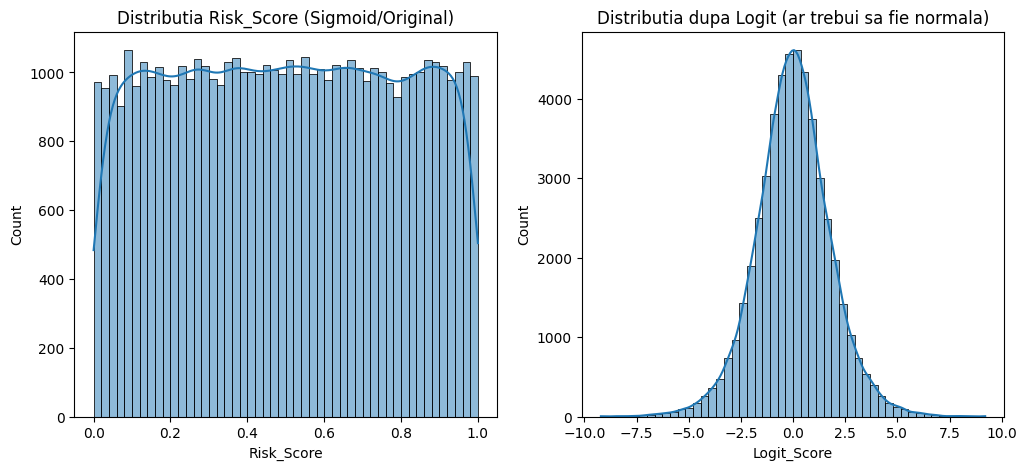

In [27]:
risk_clipped = df['Risk_Score'].clip(0.0001, 0.9999)

df['Logit_Score'] = np.log(risk_clipped / (1 - risk_clipped))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Risk_Score'], bins=50, kde=True)
plt.title('Distributia Risk_Score (Sigmoid/Original)')

plt.subplot(1, 2, 2)
sns.histplot(df['Logit_Score'], bins=50, kde=True)
plt.title('Distributia dupa Logit (ar trebui sa fie normala)')

plt.show()

In [18]:
import statsmodels.api as sm

In [25]:
df.columns[0:-1]


Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend'],
      dtype='str')

In [30]:
features = [
    'Transaction_Amount', 'Account_Balance', 'Transaction_Distance', 
    'Daily_Transaction_Count', 'IP_Address_Flag', 'Card_Age',
    'Previous_Fraudulent_Activity', 'Failed_Transaction_Count_7d'
] # fara 'Risk_Score' si 'Fraud Label'

In [29]:
df_text.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Transaction_ID         50000 non-null  str  
 1   User_ID                50000 non-null  str  
 2   Transaction_Type       50000 non-null  str  
 3   Timestamp              50000 non-null  str  
 4   Device_Type            50000 non-null  str  
 5   Location               50000 non-null  str  
 6   Merchant_Category      50000 non-null  str  
 7   Card_Type              50000 non-null  str  
 8   Authentication_Method  50000 non-null  str  
dtypes: str(9)
memory usage: 3.4 MB


In [ ]:
X = pd.get_dummies(df[features + ['Transaction_Type', 'Device_Type', 'Card_Type', 'Authentication_Method']], drop_first=True)
X = sm.add_constant(X)
y = df['Logit_Score']

model = sm.OLS(y, X.astype(float)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Logit_Score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.311
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.164
Time:                        13:08:36   Log-Likelihood:            -1.0040e+05
No. Observations:               50000   AIC:                         2.008e+05
Df Residuals:                   49980   BIC:                         2.010e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

### OBS IMPORTANTA:

-   Neasteptat: R-squared = 0.000

Variabilele date modelului explica 0% din variatia scorului de risc

-   PE SCURT NU ESTE LEGATURA LINIARA DIRECTA INTRE ACESTE VARIABILE SI Risk_Score

Avem p-values foarte mari, de exemplu Card_Age cu 0.813 > 0.05 -> nu e semnificativa statistic si sunt multe variabile cu scoruri mari, deci modelul pur si simplu ghiceste.

Deci cum a fost generat Risk_Score ?

In crearea de date sintetice se foloseste metoda "Top-Down" pentru scoruri:

-   Autorul stie cine e fraudator si cine nu (Fraud_Label)

-   Pentru a genera un Risk_Score realist, ei genereaza direct acele distributii normale in functie de clasa. De exemplu "Daca e frauda, extrage un numar aleatoriu dintr-o distributie inalata. Daca e legitim, extrage din una joasa"/

-   La final, aplica Sigmoid ca sa transforma acele numere in probabilitati

### Concluzie Risk_Score

-   A fost lipit artificial de fiecare inregistrare pe baza etichetei de frauda, fara sa fie calculat matematic din celelalte variabile